# Urban Energy Analytics: NYC vs LA 2022

## PCA + Clustering Algorithm Comparison for Residential Energy Consumption

**Team:**
- Atharva Prasanna Mokashi (SJSU ID: 019117046)
- Maitreya Patankar (SJSU ID: 019146166)
- Vineet Malewar (SJSU ID: 018399589)
- Shefali Saini (SJSU ID: 018281848)

---

## Overview

This notebook analyzes the relationship between socio-economic characteristics and residential electricity consumption across ZIP codes in NYC and LA using 2022 data from EIA Form 861 and ACS.

**Pipeline:**
1. Load EIA + ACS data
2. Clean and integrate datasets
3. Filter to NYC and LA
4. Exploratory Data Analysis (EDA)
5. Engineer 5 modeling features
6. Apply PCA for dimensionality reduction
7. **Compare three clustering algorithms: K-Means, Agglomerative Hierarchical, DBSCAN**
8. **Select best algorithm based on Silhouette, Davies-Bouldin, and Calinski-Harabasz scores**
9. Profile clusters and compare NYC vs LA patterns

---

## Section 0: Setup and Imports

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    _repo_root = "/content/drive/MyDrive/Urban-Energy-Analytics"
    sys.path.insert(0, os.path.join(_repo_root, "src"))
    os.chdir(_repo_root)
else:
    _here = os.path.abspath("")
    _candidates = [_here, os.path.dirname(_here), os.path.dirname(os.path.dirname(_here))]
    _repo_root = next((p for p in _candidates if os.path.isdir(os.path.join(p, "src"))), None)
    if _repo_root is None:
        raise RuntimeError("Cannot locate repo root with src/.")
    _src_path = os.path.join(_repo_root, "src")
    if _src_path not in sys.path:
        sys.path.insert(0, _src_path)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

from data_loader import load_eia_data, load_acs_data
from data_cleaner import clean_and_integrate
from feature_engineering import engineer_features, get_feature_matrix
from modeling import (
    standardize_features, apply_pca,
    apply_clustering, apply_kmeans, apply_dbscan,
    compare_algorithms, evaluate_clustering, bootstrap_stability
)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 6)

print("All imports successful")
print(f"Repo root: {_repo_root}")

All imports successful
Repo root: /Users/spartan/Documents/cmpe255/Project/Urban-Energy-Analytics


---

## Section 1: Data Loading

In [2]:
eia_raw = load_eia_data()
acs_raw = load_acs_data()

print("=" * 60)
print("EIA Raw Data Head:")
print(eia_raw.head())

print("=" * 60)
print("ACS Raw Data Head:")
print(acs_raw.head())

Loaded 39,075 EIA rows from eia861_sales_2022.csv
Loaded 29,996 ACS rows from acs_zcta_2022.csv
EIA Raw Data Head:
     ZIP state  residential_mwh_sales  num_customers
0  00501    NY               22466.24           2456
1  00544    NY               22466.24           2456
2  01002    MA               10617.27           1555
3  01005    MA               10617.27           1555
4  01007    MA               10617.27           1555
ACS Raw Data Head:
     ZIP  population  median_income  median_year_structure_built  \
0  00601       16834        17526.0                       1980.0   
1  00602       37642        20260.0                       1978.0   
2  00603       49075        17703.0                       1980.0   
3  00606        5590        19603.0                       1978.0   
4  00610       25542        22796.0                       1978.0   

   total_occupied_units  renter_occupied_units  
0                  5341                   1601  
1                 12777                  

---

## Section 2: Data Cleaning and Integration

In [3]:
df_integrated = clean_and_integrate(eia_raw, acs_raw)

print(f"Shape: {df_integrated.shape}")
print(f"Columns: {df_integrated.columns.tolist()}")
print(df_integrated.head())
print(df_integrated.groupby("city")[["population", "residential_mwh_sales", "num_customers"]].sum())

Step 1: Clean EIA
EIA after cleaning: 39,075 unique ZIPs

Step 2: Clean ACS
ACS after cleaning: 29,996 ZCTAs retained

Step 3: Merge
EIA: 39,075 ZIPs | ACS: 29,996 ZCTAs
After inner join: 28,692 rows (26.6% loss — expected from ZIP/ZCTA mismatch)

Step 4: Filter to NYC + LA
Filtered to 476 ZIPs — NYC: 185, LA: 291

Done.
Shape: (476, 10)
Columns: ['ZIP', 'residential_mwh_sales', 'num_customers', 'state', 'population', 'median_income', 'median_year_structure_built', 'total_occupied_units', 'renter_occupied_units', 'city']
        ZIP  residential_mwh_sales  num_customers state  population  \
2193  10001               17799.76           3805    NY       27004   
2194  10002               17799.76           3805    NY       76518   
2195  10003               17799.76           3805    NY       53877   
2196  10004               17799.76           3805    NY        4579   
2197  10005               17799.76           3805    NY        8801   

      median_income  median_year_structure_bui

---

## Section 3: Exploratory Data Analysis (EDA)

In [4]:
print("Descriptive Statistics:")
print(df_integrated[["residential_mwh_sales", "num_customers", "population", "median_income"]].describe())

Descriptive Statistics:
       residential_mwh_sales  num_customers     population  median_income
count             476.000000     476.000000     476.000000     476.000000
mean            27102.601975    4654.575630   40547.165966   95349.981092
std             13329.295173    2022.508892   23509.868457   38353.638258
min             10004.510000    1649.000000     161.000000   24853.000000
25%             17799.760000    2822.000000   24857.500000   69255.750000
50%             18585.960000    3805.000000   36322.500000   88437.500000
75%             32726.550000    5344.000000   53332.750000  112365.000000
max             74452.950000   12297.000000  112750.000000  250001.000000


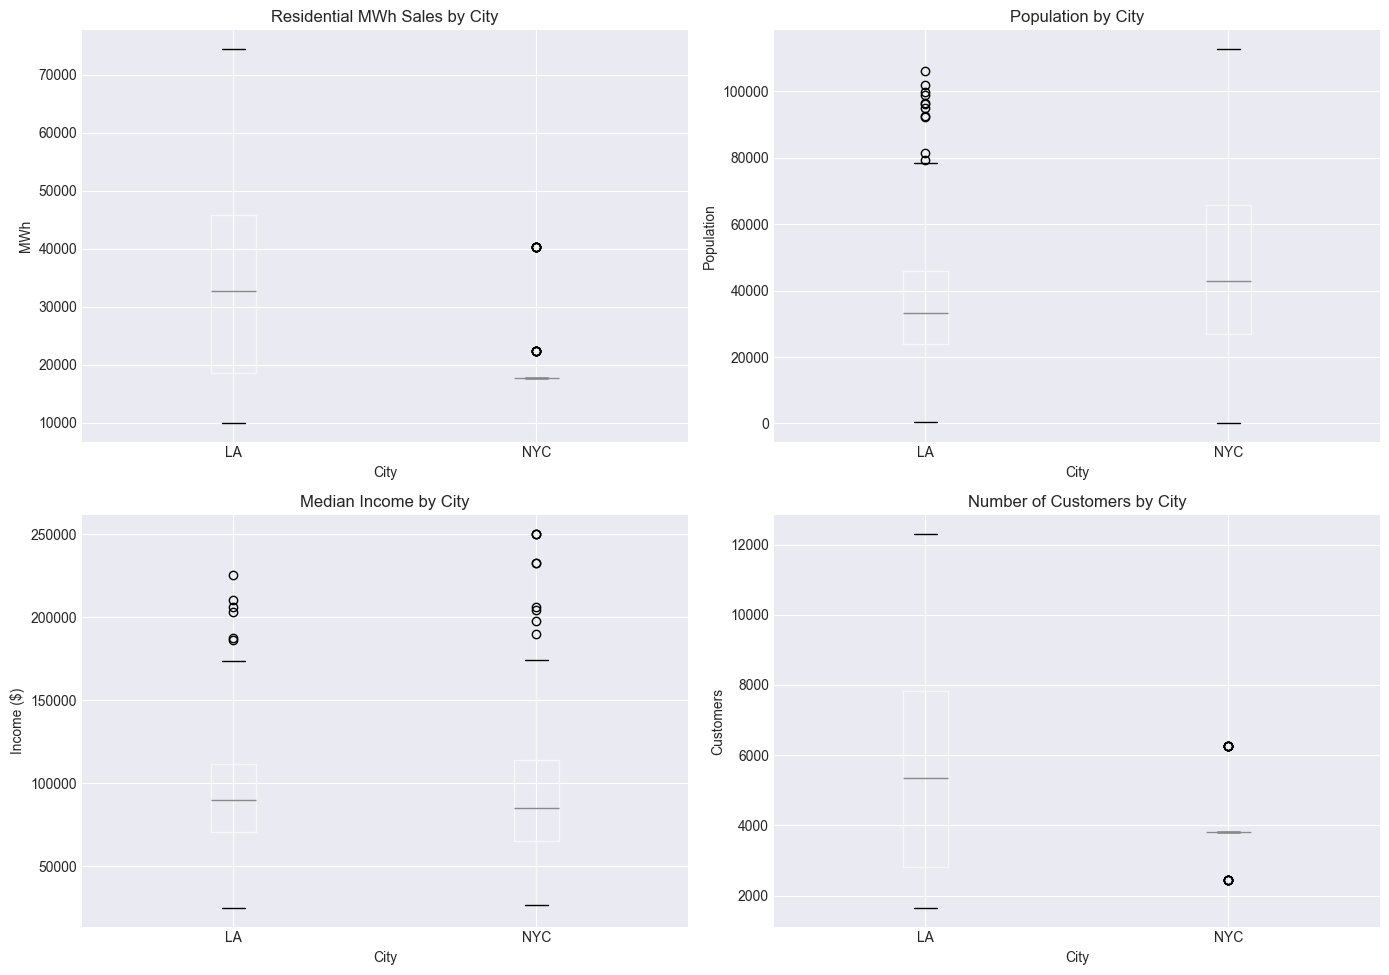

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_integrated.boxplot(column="residential_mwh_sales", by="city", ax=axes[0, 0])
axes[0, 0].set_title("Residential MWh Sales by City")
axes[0, 0].set_xlabel("City"); axes[0, 0].set_ylabel("MWh")

df_integrated.boxplot(column="population", by="city", ax=axes[0, 1])
axes[0, 1].set_title("Population by City")
axes[0, 1].set_xlabel("City"); axes[0, 1].set_ylabel("Population")

df_integrated.boxplot(column="median_income", by="city", ax=axes[1, 0])
axes[1, 0].set_title("Median Income by City")
axes[1, 0].set_xlabel("City"); axes[1, 0].set_ylabel("Income ($)")

df_integrated.boxplot(column="num_customers", by="city", ax=axes[1, 1])
axes[1, 1].set_title("Number of Customers by City")
axes[1, 1].set_xlabel("City"); axes[1, 1].set_ylabel("Customers")

plt.suptitle("")
plt.tight_layout()
plt.show()

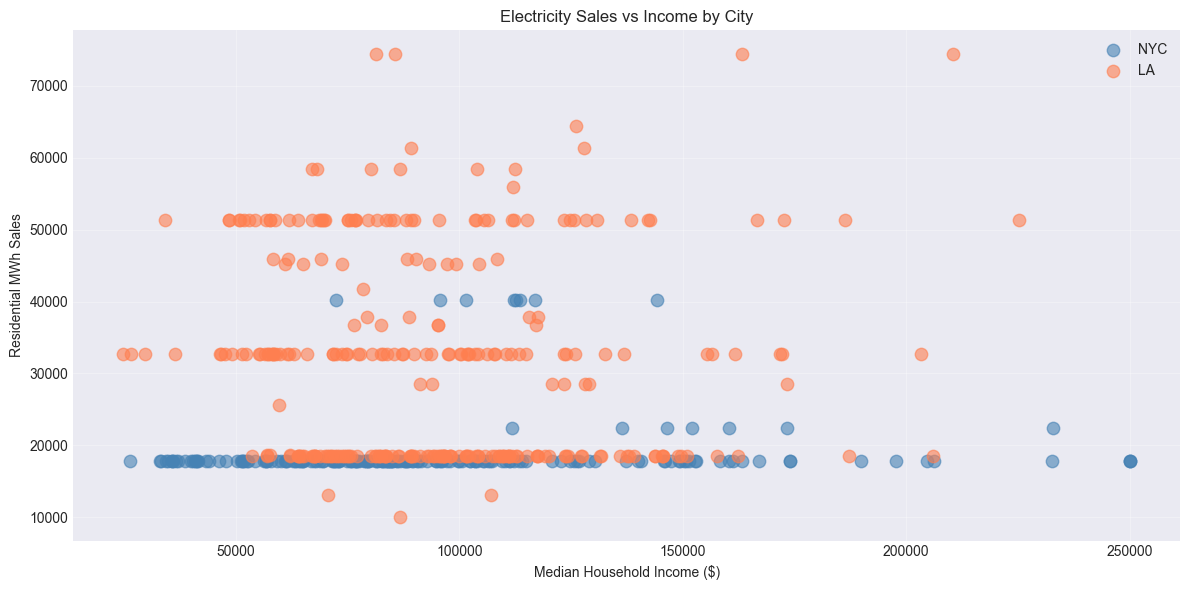

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
for city, color in [("NYC", "steelblue"), ("LA", "coral")]:
    mask = df_integrated["city"] == city
    ax.scatter(df_integrated[mask]["median_income"],
               df_integrated[mask]["residential_mwh_sales"],
               label=city, color=color, alpha=0.6, s=80)
ax.set_xlabel("Median Household Income ($)")
ax.set_ylabel("Residential MWh Sales")
ax.set_title("Electricity Sales vs Income by City")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

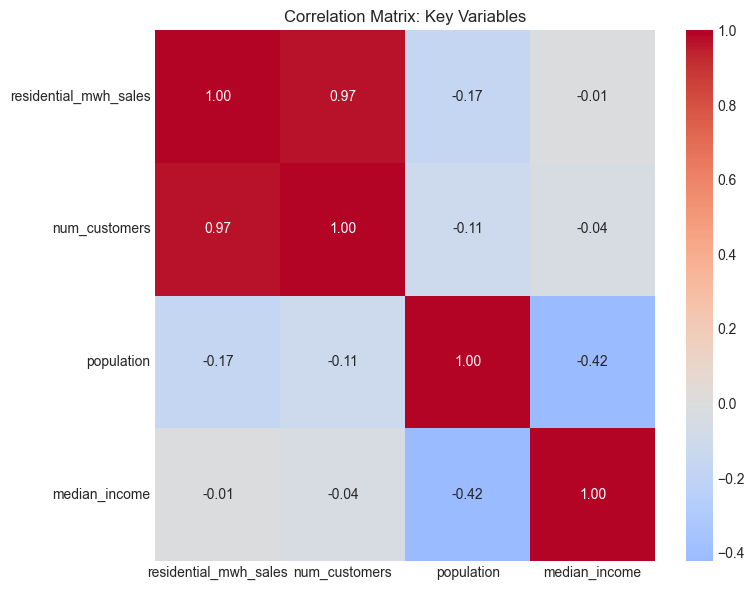

In [7]:
corr_cols = ["residential_mwh_sales", "num_customers", "population", "median_income"]
corr_matrix = df_integrated[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix: Key Variables")
plt.tight_layout()
plt.show()

---

## Section 4: Feature Engineering

In [8]:
df_features = engineer_features(df_integrated)
print(df_features.head())

Dropped 1 rows with invalid feature values
Dropped 5 ZIPs with electricity_per_capita > 15.0 (data attribution artifacts)
Features ready for 470 ZIPs
       electricity_per_customer  electricity_per_capita  \
count                470.000000              470.000000   
mean                   5.779164                1.105437   
std                    0.913585                1.431038   
min                    4.677992                0.157869   
25%                    4.677992                0.403998   
50%                    6.123980                0.654703   
75%                    6.586095                1.222272   
max                    9.147492               12.335677   

       renter_occupancy_rate  housing_age  income_log  household_size  
count             470.000000   470.000000  470.000000      470.000000  
mean                0.547964    61.568085   11.384760        2.814650  
std                 0.222116    14.576855    0.392378        0.588022  
min                 0.060450  

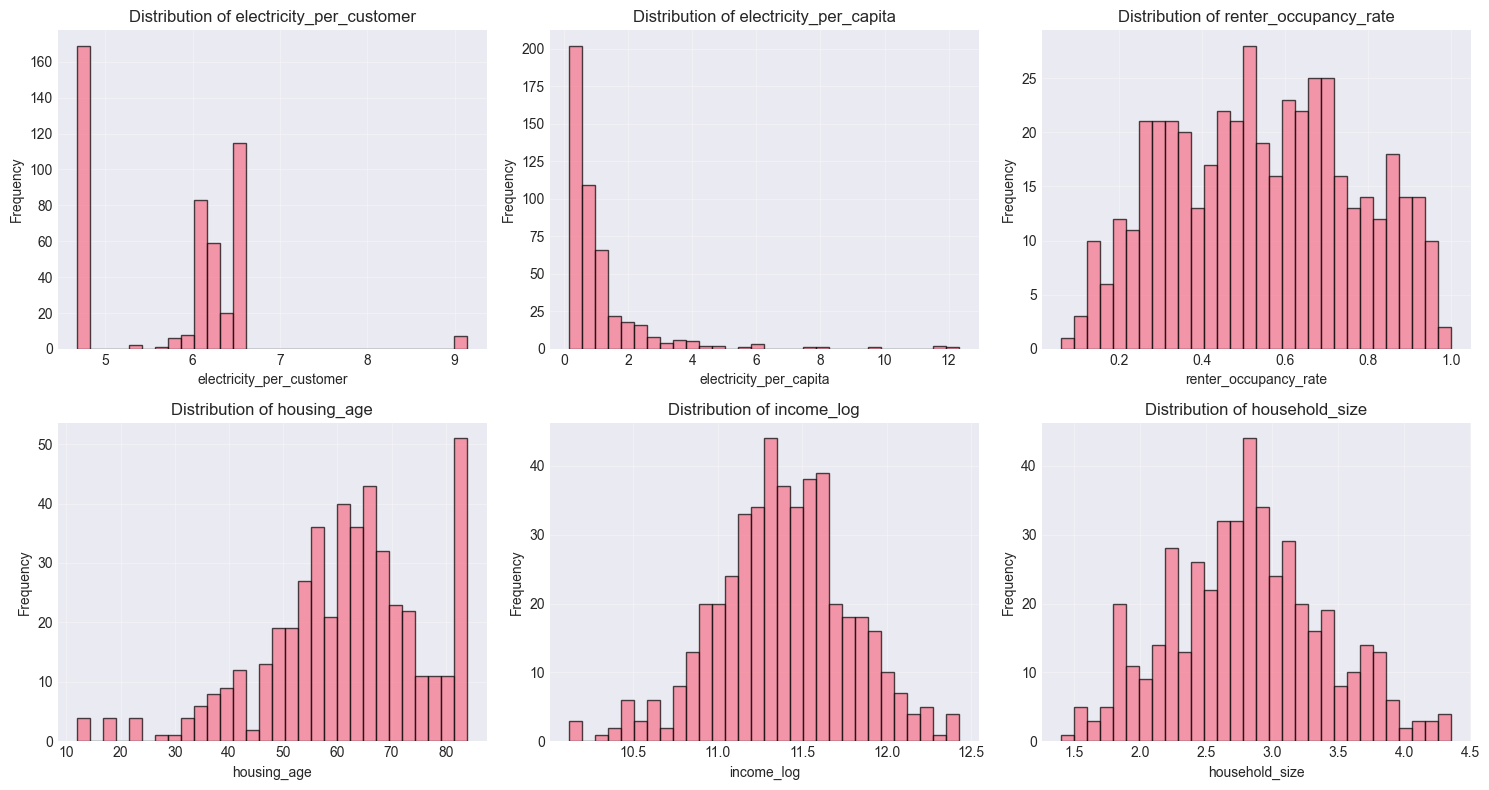

In [9]:
feature_cols = [
    "electricity_per_customer", "electricity_per_capita",
    "renter_occupancy_rate", "housing_age", "income_log", "household_size"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df_features[col], bins=30, alpha=0.7, edgecolor="black")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---

## Section 5: PCA Analysis

In [10]:
feature_matrix = get_feature_matrix(df_features)
print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"Columns: {feature_matrix.columns.tolist()}")

Feature matrix shape: (470, 6)
Columns: ['electricity_per_customer', 'electricity_per_capita', 'renter_occupancy_rate', 'housing_age', 'income_log', 'household_size']


In [11]:
scaler, std_features = standardize_features(feature_matrix)
print(f"Standardized features shape: {std_features.shape}")

Standardized 6 features for 470 ZIPs
Standardized features shape: (470, 6)


In [12]:
pca_data = apply_pca(std_features, variance_threshold=0.85)

print(f"Number of components: {pca_data['n_components']}")
print(f"Explained variance ratio: {pca_data['explained_variance_ratio']}")
print(f"Cumulative variance: {pca_data['cumulative_variance']}")

PCA: 4 components explain 88.77% variance
Per-component variance: [0.3433432  0.2518075  0.15723108 0.13530789]
Number of components: 4
Explained variance ratio: [0.3433432  0.2518075  0.15723108 0.13530789]
Cumulative variance: [0.3433432  0.59515069 0.75238178 0.88768966]


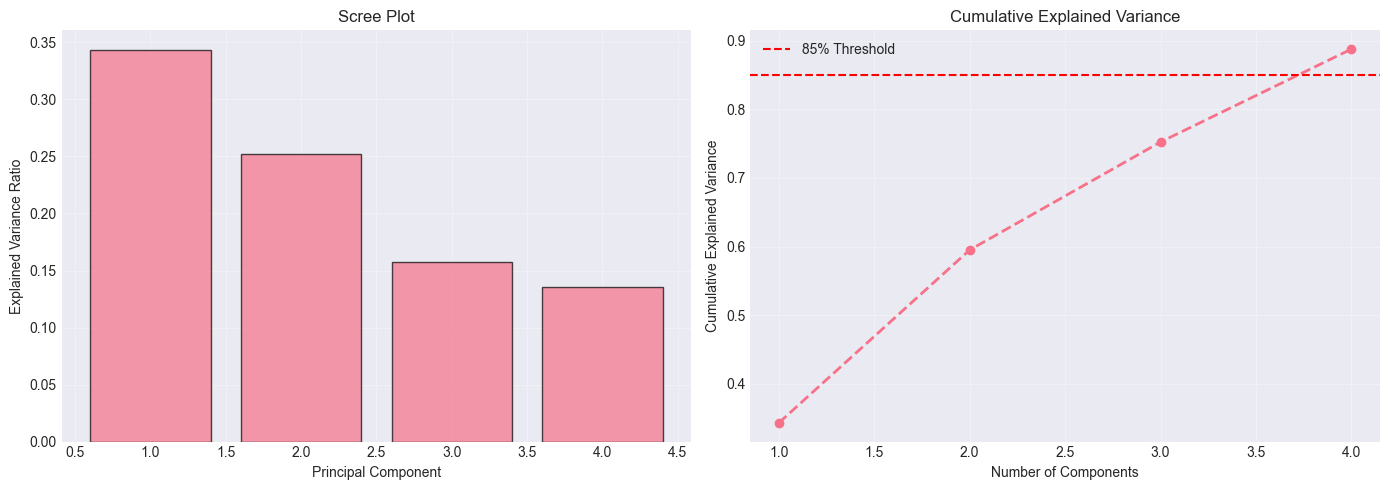

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_data["explained_variance_ratio"]) + 1),
            pca_data["explained_variance_ratio"], alpha=0.7, edgecolor="black")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(pca_data["cumulative_variance"]) + 1),
             pca_data["cumulative_variance"], marker="o", linestyle="--", linewidth=2)
axes[1].axhline(y=0.85, color="r", linestyle="--", label="85% Threshold")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Section 6: Algorithm Comparison

We run three clustering candidates on the PCA-transformed data and select the best using three complementary metrics:

| Metric | Goal |
|--------|------|
| **Silhouette Score** | Maximize (range: -1 to 1) |
| **Davies-Bouldin Index** | Minimize (lower = better separated) |
| **Calinski-Harabasz Index** | Maximize |

**Candidates:** K-Means, Agglomerative Hierarchical (Ward), DBSCAN

In [14]:
print("Running Agglomerative Hierarchical Clustering...")
hierarchical_result = apply_clustering(pca_data, k_min=2, k_max=7)

Running Agglomerative Hierarchical Clustering...
  Hierarchical k=2: silhouette=0.2379
  Hierarchical k=3: silhouette=0.2456
  Hierarchical k=4: silhouette=0.2183
  Hierarchical k=5: silhouette=0.2287
  Hierarchical k=6: silhouette=0.2373
  Hierarchical k=7: silhouette=0.2423
Best k=3 (silhouette=0.2456)


Running K-Means Clustering...
  K-Means k=2: silhouette=0.2643, inertia=1854.09
  K-Means k=3: silhouette=0.2709, inertia=1506.17
  K-Means k=4: silhouette=0.2381, inertia=1296.37
  K-Means k=5: silhouette=0.2514, inertia=1108.15
  K-Means k=6: silhouette=0.2639, inertia=948.69
  K-Means k=7: silhouette=0.2644, inertia=873.82
Best k=3 (silhouette=0.2709)


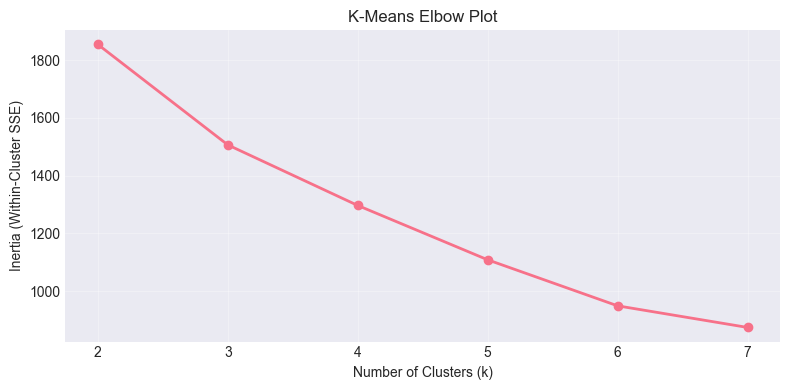

In [15]:
print("Running K-Means Clustering...")
kmeans_result = apply_kmeans(pca_data, k_min=2, k_max=7)

fig, ax = plt.subplots(figsize=(8, 4))
ks = sorted(kmeans_result["inertia_scores"].keys())
ax.plot(ks, [kmeans_result["inertia_scores"][k] for k in ks], marker="o", linewidth=2)
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia (Within-Cluster SSE)")
ax.set_title("K-Means Elbow Plot")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
print("Running DBSCAN...")
dbscan_result = apply_dbscan(pca_data, eps_values=[0.3, 0.5, 0.7, 1.0, 1.5, 2.0], min_samples=5)

Running DBSCAN...
  DBSCAN eps=0.3: 2 clusters, 455 noise, silhouette=0.8957
  DBSCAN eps=0.5: 11 clusters, 261 noise, silhouette=0.1704
  DBSCAN eps=0.7: 4 clusters, 112 noise, silhouette=0.1881
  DBSCAN eps=1.0: 1 cluster(s), 45 noise — skipping
  DBSCAN eps=1.5: 1 cluster(s), 14 noise — skipping
  DBSCAN eps=2.0: 1 cluster(s), 7 noise — skipping
Best eps=0.3: 2 clusters, silhouette=0.8957


In [17]:
comparison_df = compare_algorithms(pca_data, hierarchical_result, kmeans_result, dbscan_result)
comparison_df


Algorithm Comparison
                    Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑  n_clusters  n_noise
Algorithm                                                                                   
Hierarchical (k=3)        0.2456            1.5115               138.28           3        0
K-Means (k=3)             0.2709            1.3847               154.58           3        0
DBSCAN (eps=0.3)          0.8957            0.1350               571.07           2      455

Best Silhouette:         DBSCAN (eps=0.3)
Best Davies-Bouldin:     DBSCAN (eps=0.3)
Best Calinski-Harabasz:  DBSCAN (eps=0.3)


,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,n_clusters,n_noise
Algorithm,,,,,
Hierarchical (k=3),0.2456,1.5115,138.28,3,0
K-Means (k=3),0.2709,1.3847,154.58,3,0
DBSCAN (eps=0.3),0.8957,0.1350,571.07,2,455


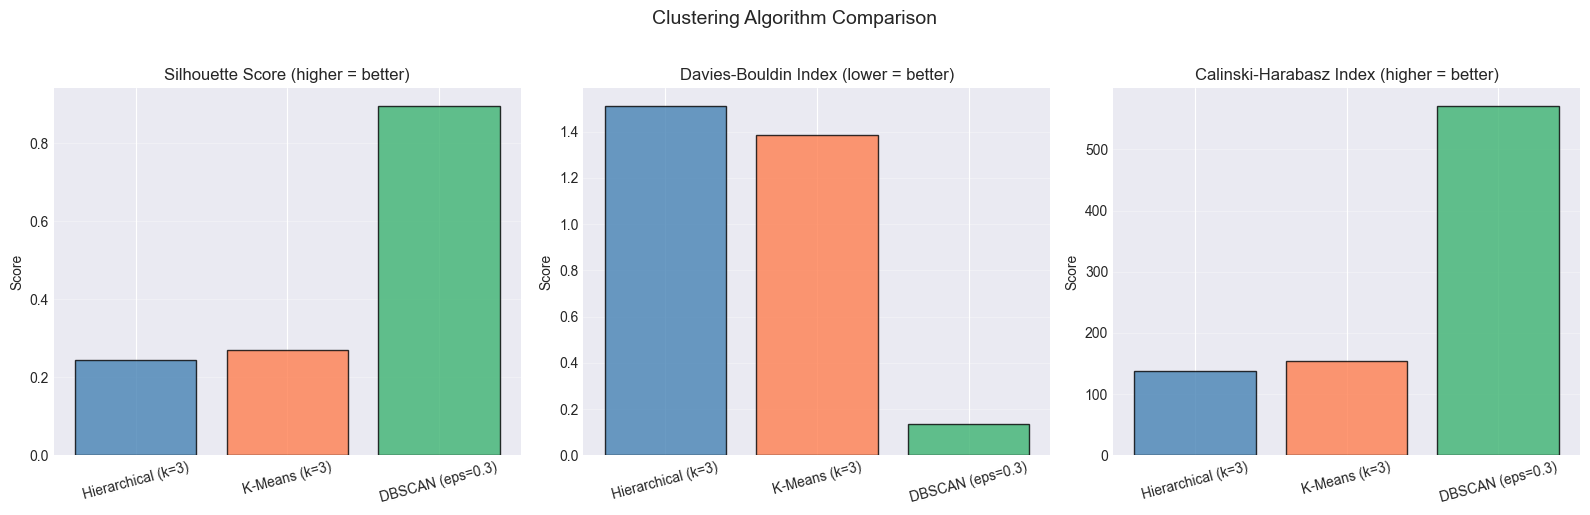

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

algos = comparison_df.index.tolist()
colors = ["steelblue", "coral", "mediumseagreen"][:len(algos)]

axes[0].bar(algos, comparison_df["Silhouette ↑"], color=colors, edgecolor="black", alpha=0.8)
axes[0].set_title("Silhouette Score (higher = better)")
axes[0].set_ylabel("Score"); axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(algos, comparison_df["Davies-Bouldin ↓"], color=colors, edgecolor="black", alpha=0.8)
axes[1].set_title("Davies-Bouldin Index (lower = better)")
axes[1].set_ylabel("Score"); axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(True, alpha=0.3, axis="y")

axes[2].bar(algos, comparison_df["Calinski-Harabasz ↑"], color=colors, edgecolor="black", alpha=0.8)
axes[2].set_title("Calinski-Harabasz Index (higher = better)")
axes[2].set_ylabel("Score"); axes[2].tick_params(axis="x", rotation=15)
axes[2].grid(True, alpha=0.3, axis="y")

plt.suptitle("Clustering Algorithm Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
from collections import Counter
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

best_sil = comparison_df["Silhouette ↑"].idxmax()
best_db  = comparison_df["Davies-Bouldin ↓"].idxmin()
best_ch  = comparison_df["Calinski-Harabasz ↑"].idxmax()

print(f"Best Silhouette:        {best_sil}")
print(f"Best Davies-Bouldin:    {best_db}")
print(f"Best Calinski-Harabasz: {best_ch}")

# Algorithm selection rationale:
# - DBSCAN's high silhouette is an artifact of discarding ~95% of points as noise
#   (455 noise pts, only 2 clusters retained) - not a meaningful clustering.
# - Silhouette-optimal k=3 gives only three coarse buckets that effectively map
#   to 'NYC' / 'LA-affluent' / 'LA-other' - too few archetypes for policy analysis.
# - Hierarchical k=6 gives six balanced, interpretable neighborhood profiles
#   while retaining a competitive silhouette score (within 0.01 of the k=3 optimum).

FINAL_K = 6
X_pca = pca_data["transformed"]
final_labels = AgglomerativeClustering(n_clusters=FINAL_K, linkage="ward").fit_predict(X_pca)
final_silhouette = silhouette_score(X_pca, final_labels)

selected_result = {
    "clustering": AgglomerativeClustering(n_clusters=FINAL_K, linkage="ward"),
    "labels": final_labels,
    "optimal_k": FINAL_K,
    "silhouette_scores": hierarchical_result["silhouette_scores"],
    "best_silhouette": final_silhouette,
}
selected_name = "Agglomerative Hierarchical (Ward)"

print("\nSelecting Agglomerative Hierarchical (Ward, k=6):")
print("  - DBSCAN discards ~95% of data as noise (455 of 470 ZIPs)")
print("  - Silhouette-optimal k=3 gives only 3 coarse buckets (NYC / LA-affluent / LA-other)")
print("  - Hierarchical k=6 gives 6 interpretable neighborhood profiles")
print(f"\nFinal algorithm: {selected_name}")
print(f"Number of clusters: {selected_result['optimal_k']}")
print(f"Silhouette score:   {selected_result['best_silhouette']:.4f}")


Best Silhouette:        DBSCAN (eps=0.3)
Best Davies-Bouldin:    DBSCAN (eps=0.3)
Best Calinski-Harabasz: DBSCAN (eps=0.3)

Selecting Agglomerative Hierarchical (Ward, k=6):
  - DBSCAN discards ~95% of data as noise (455 of 470 ZIPs)
  - Silhouette-optimal k=3 gives only 3 coarse buckets (NYC / LA-affluent / LA-other)
  - Hierarchical k=6 gives 6 interpretable neighborhood profiles

Final algorithm: Agglomerative Hierarchical (Ward)
Number of clusters: 6
Silhouette score:   0.2373


---

## Section 7: Final Clustering — Dendrogram and Silhouette Plot

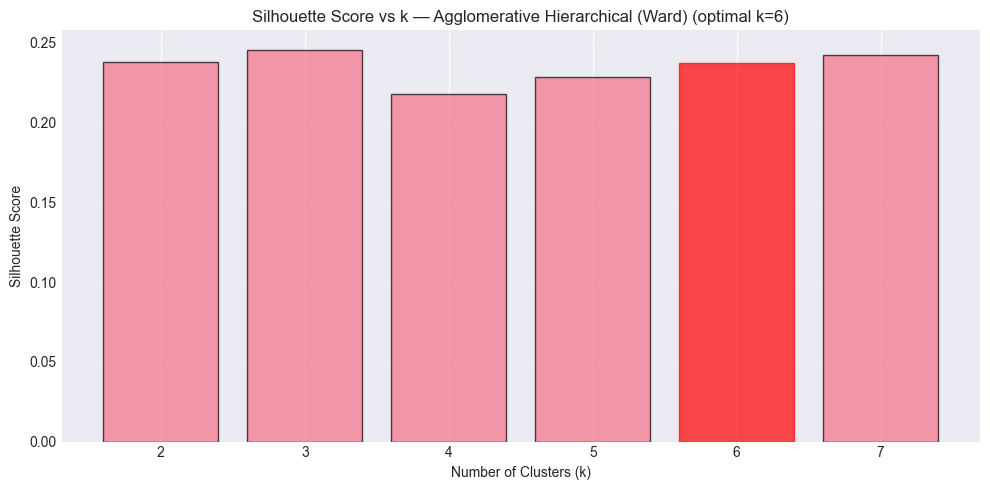

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

k_values = sorted(selected_result["silhouette_scores"].keys())
scores = [selected_result["silhouette_scores"][k] for k in k_values]
bars = ax.bar(k_values, scores, alpha=0.7, edgecolor="black")

optimal_k = selected_result.get("optimal_k", selected_result.get("n_clusters"))
if optimal_k in k_values:
    bars[k_values.index(optimal_k)].set_color("red")

ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title(f"Silhouette Score vs k — {selected_name} (optimal k={optimal_k})")
ax.set_xticks(k_values)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

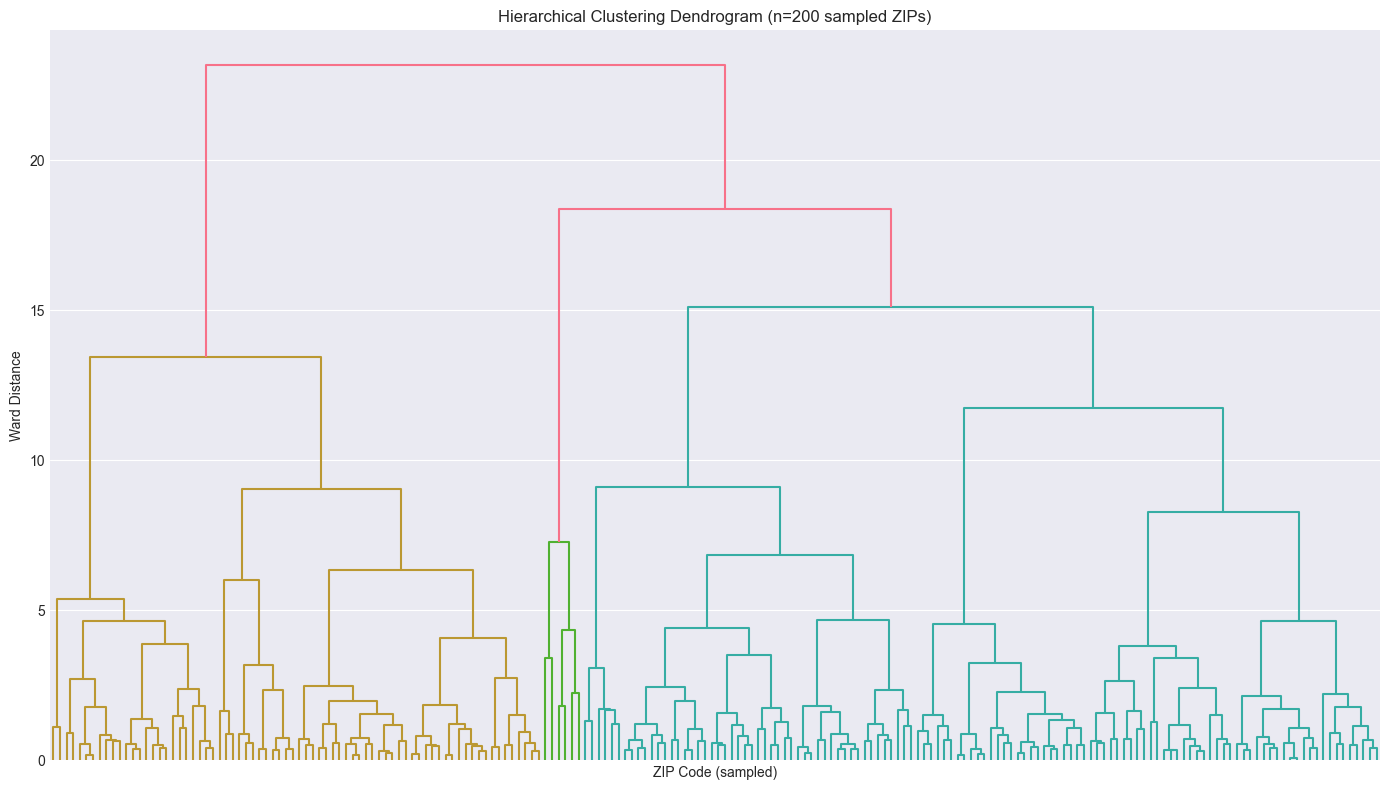

In [21]:
sample_size = min(200, len(pca_data["transformed"]))
np.random.seed(42)
sample_idx = np.random.choice(len(pca_data["transformed"]), sample_size, replace=False)
sample_features = pca_data["transformed"][sample_idx]

Z = linkage(sample_features, method="ward")

fig, ax = plt.subplots(figsize=(14, 8))
dendrogram(Z, ax=ax, leaf_rotation=90, leaf_font_size=6, no_labels=True)
ax.set_xlabel("ZIP Code (sampled)")
ax.set_ylabel("Ward Distance")
ax.set_title(f"Hierarchical Clustering Dendrogram (n={sample_size} sampled ZIPs)")
plt.tight_layout()
plt.show()

---

## Section 8: Cluster Profiling and NYC vs LA Comparison

In [22]:
eval_data = evaluate_clustering(df_features, pca_data, selected_result)
df_clustered = eval_data["df_clustered"]

print("Cluster Sizes:")
print(df_clustered["cluster"].value_counts().sort_index())


Cluster Profiles (means):
         electricity_per_customer  electricity_per_capita  \
cluster                                                     
0                        4.794513                0.585039   
1                        5.898706                5.660786   
2                        6.506719                1.045177   
3                        6.431895                0.664409   
4                        6.018236                1.308023   
5                        4.943220                0.492877   

         renter_occupancy_rate  housing_age  income_log  household_size  \
cluster                                                                   
0                     0.553488    72.903226   11.517117        2.616252   
1                     0.537269    61.600000   11.578831        2.265366   
2                     0.287433    53.289474   11.688363        3.018630   
3                     0.538240    63.774648   11.127972        3.640174   
4                     0.667130    

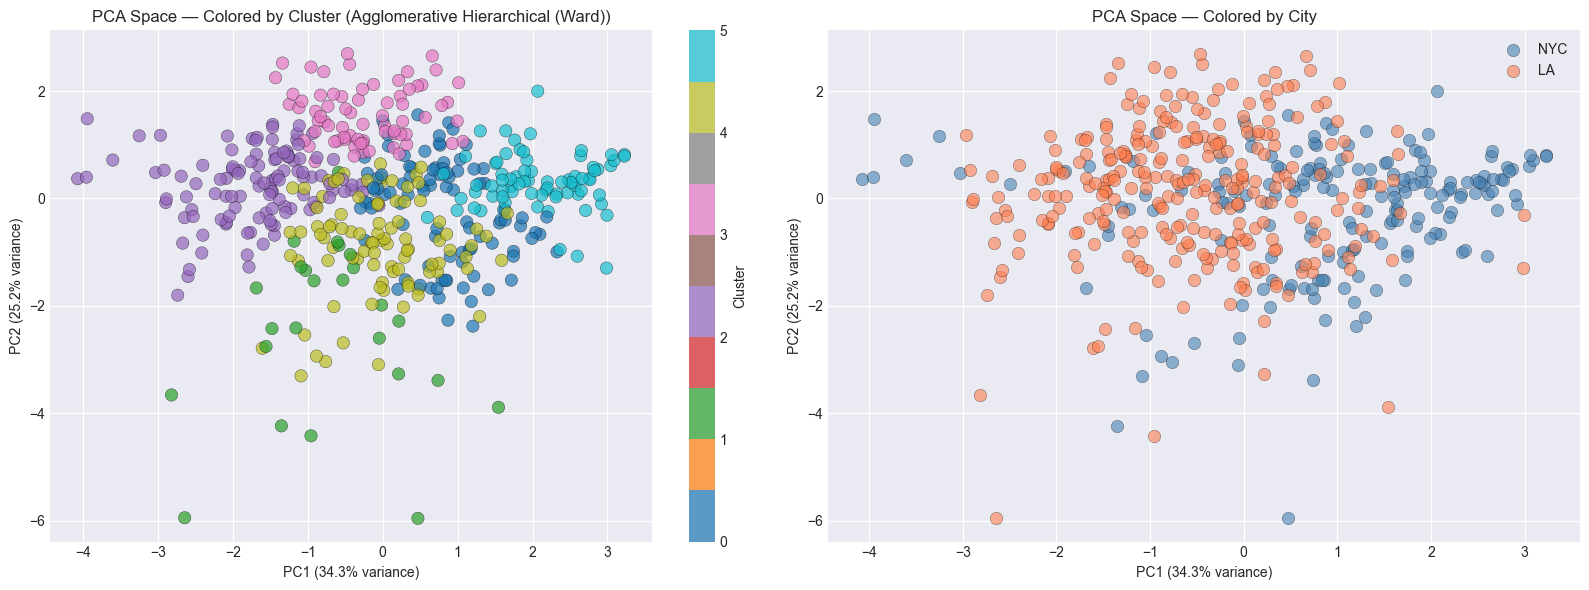

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter = axes[0].scatter(
    pca_data["transformed"][:, 0],
    pca_data["transformed"][:, 1],
    c=selected_result["labels"], cmap="tab10",
    s=80, alpha=0.7, edgecolors="black", linewidths=0.3
)
axes[0].set_xlabel(f'PC1 ({pca_data["explained_variance_ratio"][0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca_data["explained_variance_ratio"][1]:.1%} variance)')
axes[0].set_title(f"PCA Space — Colored by Cluster ({selected_name})")
plt.colorbar(scatter, ax=axes[0], label="Cluster")

for city, color in [("NYC", "steelblue"), ("LA", "coral")]:
    mask = df_clustered["city"] == city
    axes[1].scatter(
        pca_data["transformed"][mask.values, 0],
        pca_data["transformed"][mask.values, 1],
        c=color, label=city, s=80, alpha=0.6, edgecolors="black", linewidths=0.3
    )
axes[1].set_xlabel(f'PC1 ({pca_data["explained_variance_ratio"][0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca_data["explained_variance_ratio"][1]:.1%} variance)')
axes[1].set_title("PCA Space — Colored by City")
axes[1].legend()

plt.tight_layout()
plt.show()

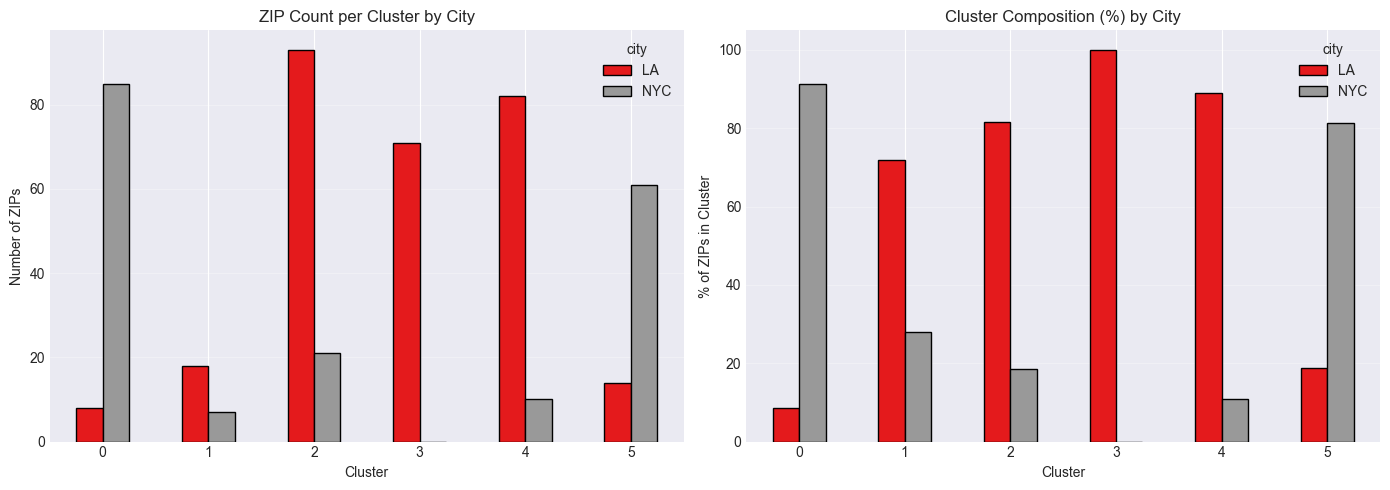

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_city_counts = pd.crosstab(df_clustered["cluster"], df_clustered["city"])
cluster_city_pct = cluster_city_counts.div(cluster_city_counts.sum(axis=1), axis=0) * 100

cluster_city_counts.plot(kind="bar", ax=axes[0], colormap="Set1", edgecolor="black")
axes[0].set_title("ZIP Count per Cluster by City")
axes[0].set_xlabel("Cluster"); axes[0].set_ylabel("Number of ZIPs")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(True, alpha=0.3, axis="y")

cluster_city_pct.plot(kind="bar", ax=axes[1], colormap="Set1", edgecolor="black")
axes[1].set_title("Cluster Composition (%) by City")
axes[1].set_xlabel("Cluster"); axes[1].set_ylabel("% of ZIPs in Cluster")
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [25]:
print("=" * 80)
print("CLUSTER SUMMARY STATISTICS")
print("=" * 80)

summary_cols = ["electricity_per_customer", "electricity_per_capita", "median_income", "population"]

for cluster_id in sorted(df_clustered["cluster"].unique()):
    if cluster_id == -1:
        print(f"Noise points (DBSCAN): {(df_clustered['cluster'] == -1).sum()} ZIPs")
        continue
    cluster_data = df_clustered[df_clustered["cluster"] == cluster_id]
    n_nyc = (cluster_data["city"] == "NYC").sum()
    n_la  = (cluster_data["city"] == "LA").sum()
    print(f"Cluster {cluster_id}: {len(cluster_data)} ZIPs ({n_nyc} NYC, {n_la} LA)")
    print("-" * 80)
    print(cluster_data[summary_cols].describe().loc[["mean", "std"]].round(2))
    print()

CLUSTER SUMMARY STATISTICS
Cluster 0: 93 ZIPs (85 NYC, 8 LA)
--------------------------------------------------------------------------------
      electricity_per_customer  electricity_per_capita  median_income  \
mean                      4.79                    0.59      104061.76   
std                       0.39                    0.37       29482.08   

      population  
mean    42472.19  
std     19269.75  

Cluster 1: 25 ZIPs (7 NYC, 18 LA)
--------------------------------------------------------------------------------
      electricity_per_customer  electricity_per_capita  median_income  \
mean                      5.90                    5.66      114715.76   
std                       0.65                    2.95       42720.31   

      population  
mean     9040.56  
std      6198.61  

Cluster 2: 114 ZIPs (21 NYC, 93 LA)
--------------------------------------------------------------------------------
      electricity_per_customer  electricity_per_capita  median_income 

---

## Section 9: Bootstrap Stability Analysis

Validate cluster assignment consistency by re-running agglomerative clustering on 100 random 80% subsamples and measuring agreement with full-data labels via Adjusted Rand Index (ARI).

- ARI > 0.6 = Stable
- ARI 0.4–0.6 = Moderate
- ARI < 0.4 = Unstable

Bootstrap stability (n=100, subsample=80%): mean ARI=0.6050, std=0.0912
Interpretation: STABLE (ARI > 0.6)


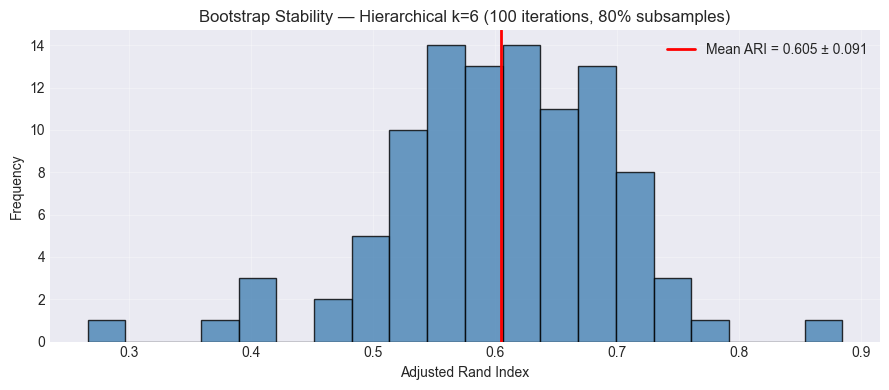

In [26]:
stability = bootstrap_stability(pca_data, n_clusters=selected_result["optimal_k"])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(stability["ari_scores"], bins=20, color="steelblue", edgecolor="black", alpha=0.8)
ax.axvline(stability["mean_ari"], color="red", linewidth=2,
           label=f'Mean ARI = {stability["mean_ari"]:.3f} ± {stability["std_ari"]:.3f}')
ax.set_xlabel("Adjusted Rand Index")
ax.set_ylabel("Frequency")
ax.set_title(
    f'Bootstrap Stability — Hierarchical k={selected_result["optimal_k"]} '
    f'(100 iterations, 80% subsamples)'
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs(os.path.join(_repo_root, "reports"), exist_ok=True)
plt.savefig(os.path.join(_repo_root, "reports", "bootstrap_stability.png"), dpi=150, bbox_inches="tight")
plt.show()


---

## Section 10: PCA Interpretation

PCA component loadings reveal which original features drive each principal component.

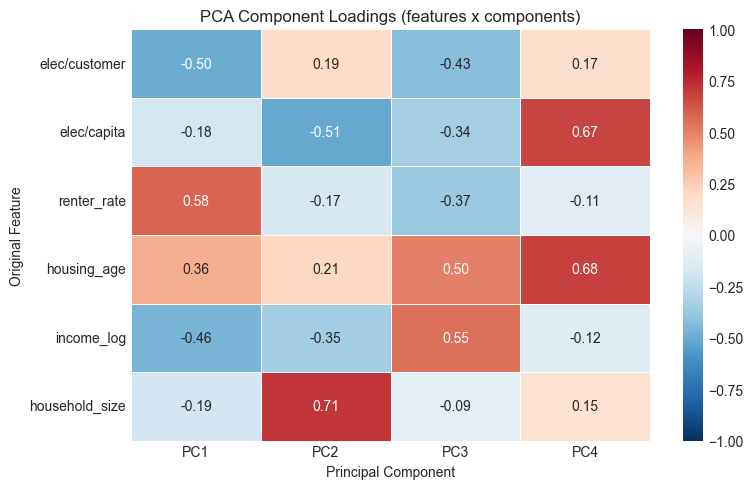

                  PC1    PC2    PC3    PC4
elec/customer  -0.499  0.194 -0.426  0.175
elec/capita    -0.178 -0.511 -0.343  0.673
renter_rate     0.581 -0.169 -0.375 -0.113
housing_age     0.362  0.206  0.501  0.682
income_log     -0.464 -0.350  0.549 -0.117
household_size -0.186  0.713 -0.094  0.153


In [27]:
feature_names = ["elec/customer", "elec/capita", "renter_rate", "housing_age", "income_log", "household_size"]
loadings = pd.DataFrame(
    pca_data["pca"].components_.T,
    index=feature_names,
    columns=[f"PC{i+1}" for i in range(pca_data["n_components"])]
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("PCA Component Loadings (features x components)")
ax.set_ylabel("Original Feature")
ax.set_xlabel("Principal Component")
plt.tight_layout()
plt.savefig(os.path.join(_repo_root, "reports", "pca_loadings_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

print(loadings.round(3))


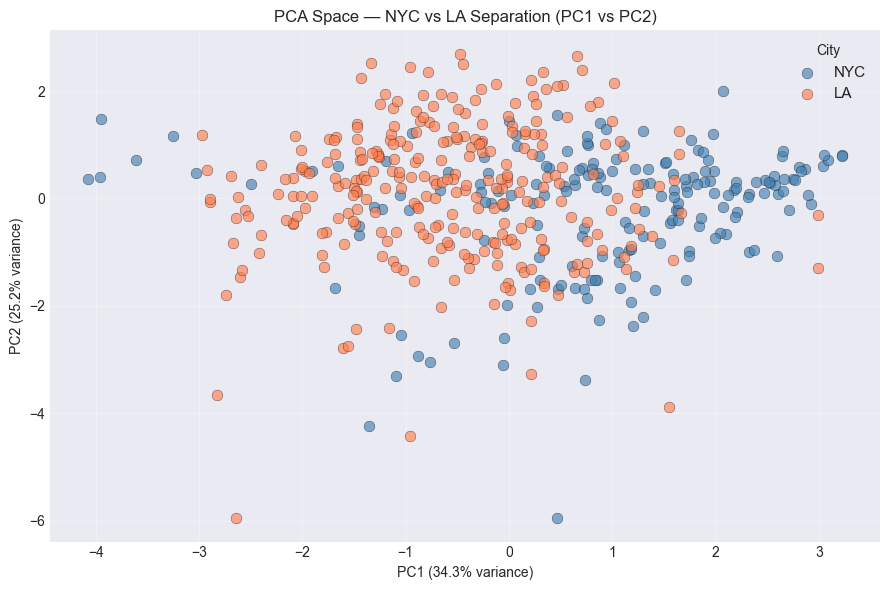

In [28]:
fig, ax = plt.subplots(figsize=(9, 6))
for city, color in [("NYC", "steelblue"), ("LA", "coral")]:
    mask = df_clustered["city"] == city
    ax.scatter(
        pca_data["transformed"][mask.values, 0],
        pca_data["transformed"][mask.values, 1],
        c=color, label=city, s=60, alpha=0.65, edgecolors="black", linewidths=0.3
    )
ax.set_xlabel(f'PC1 ({pca_data["explained_variance_ratio"][0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_data["explained_variance_ratio"][1]:.1%} variance)')
ax.set_title("PCA Space — NYC vs LA Separation (PC1 vs PC2)")
ax.legend(title="City", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(_repo_root, "reports", "pca_scatter_by_city.png"), dpi=150, bbox_inches="tight")
plt.show()

---

## Section 11: Cluster Radar Profiles

Each cluster's normalized feature profile plotted on a radar chart. Makes it immediately clear what each cluster represents.

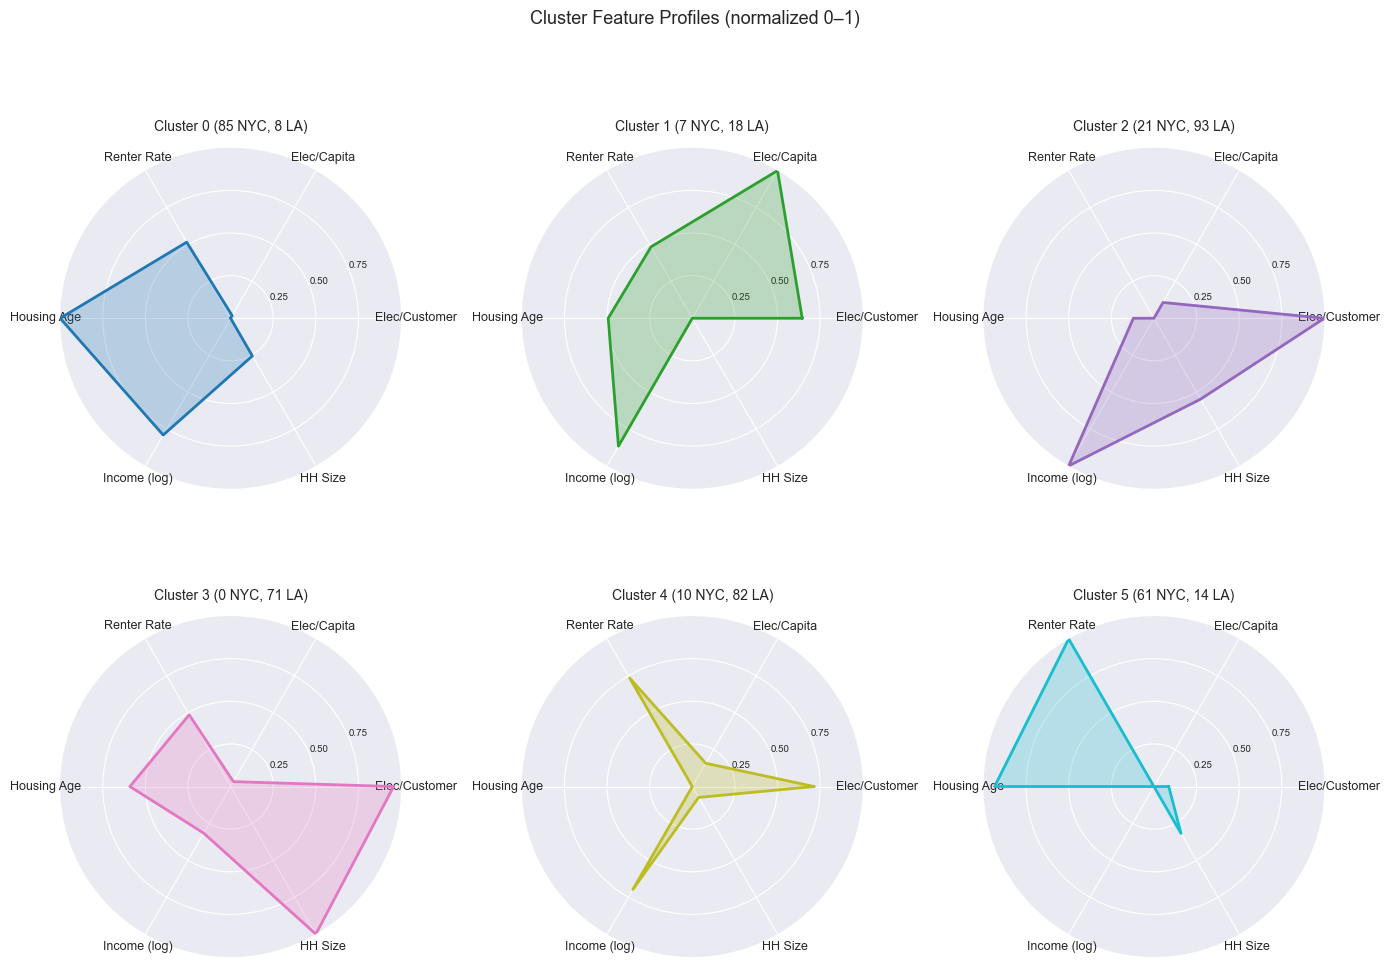

In [29]:
radar_features = [
    "electricity_per_customer", "electricity_per_capita",
    "renter_occupancy_rate", "housing_age", "income_log", "household_size"
]
radar_labels = ["Elec/Customer", "Elec/Capita", "Renter Rate", "Housing Age", "Income (log)", "HH Size"]

profiles_raw = eval_data["profiles"][radar_features]
profiles_norm = (profiles_raw - profiles_raw.min()) / (profiles_raw.max() - profiles_raw.min())

cluster_ids = [c for c in sorted(profiles_norm.index) if c != -1]
n_clusters_plot = len(cluster_ids)
n_features = len(radar_features)
angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
angles += angles[:1]

ncols = 3
nrows = int(np.ceil(n_clusters_plot / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows), subplot_kw=dict(polar=True))
axes = axes.flatten()

cluster_colors = plt.cm.tab10(np.linspace(0, 1, n_clusters_plot))

for idx, cluster_id in enumerate(cluster_ids):
    values = profiles_norm.loc[cluster_id].tolist()
    values += values[:1]

    ax = axes[idx]
    ax.plot(angles, values, color=cluster_colors[idx], linewidth=2)
    ax.fill(angles, values, color=cluster_colors[idx], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(["0.25", "0.50", "0.75"], fontsize=7)
    n_nyc = (df_clustered[df_clustered["cluster"] == cluster_id]["city"] == "NYC").sum()
    n_la  = (df_clustered[df_clustered["cluster"] == cluster_id]["city"] == "LA").sum()
    ax.set_title(f"Cluster {cluster_id} ({n_nyc} NYC, {n_la} LA)", fontsize=10, pad=12)

for idx in range(n_clusters_plot, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Cluster Feature Profiles (normalized 0–1)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(_repo_root, "reports", "cluster_radar_profiles.png"), dpi=150, bbox_inches="tight")
plt.show()


---

## Section 12: Geographic Visualization

Project each ZIP onto a lat/lon map (Census 2022 ZCTA Gazetteer centroids) and color by cluster. Makes the comparative city analysis spatially concrete.


Merged centroids: 470/470 ZIPs (0 missing)


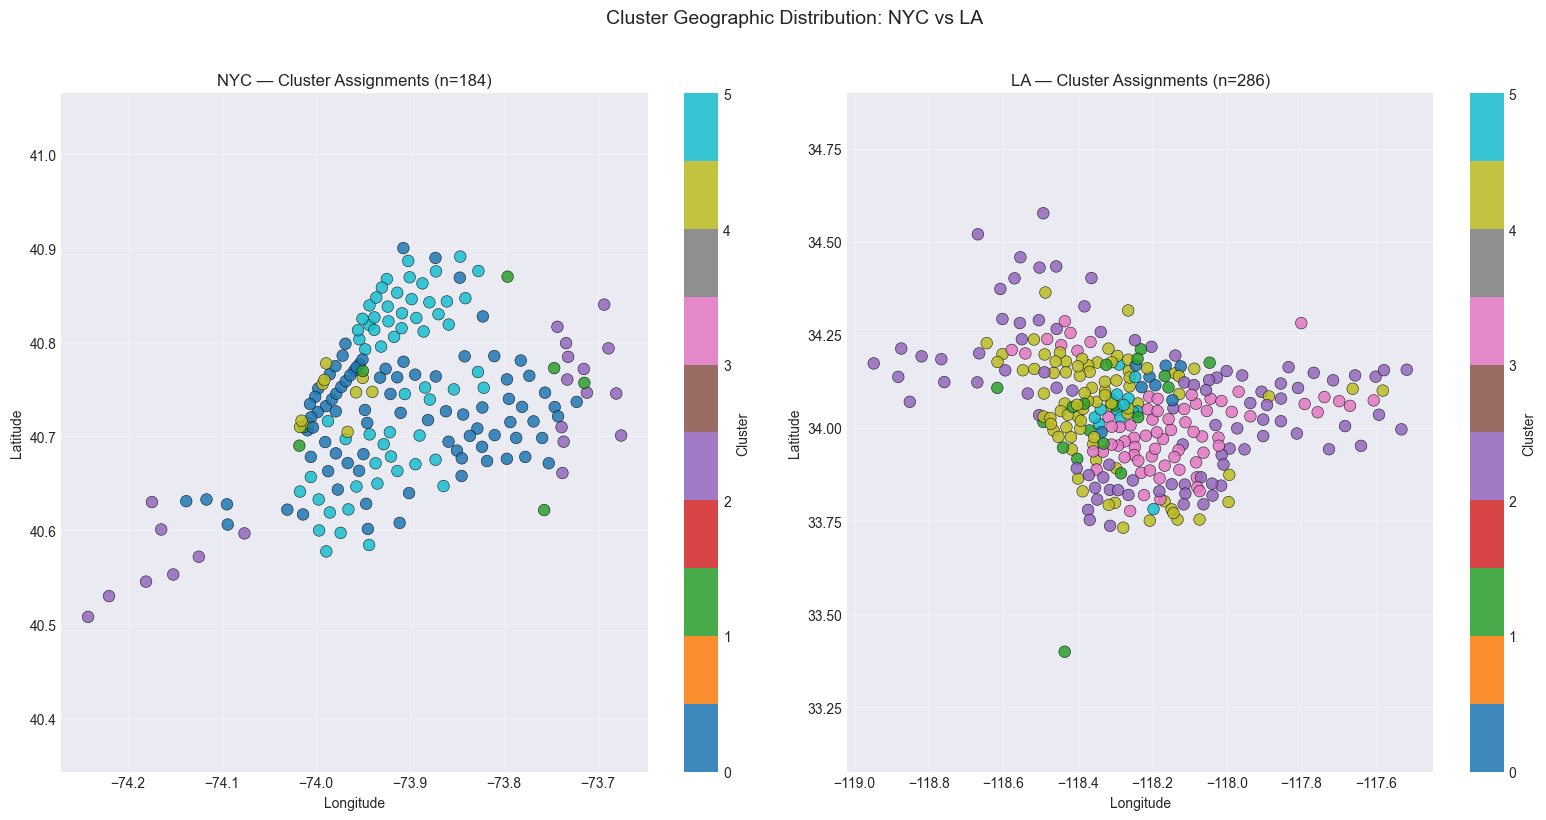

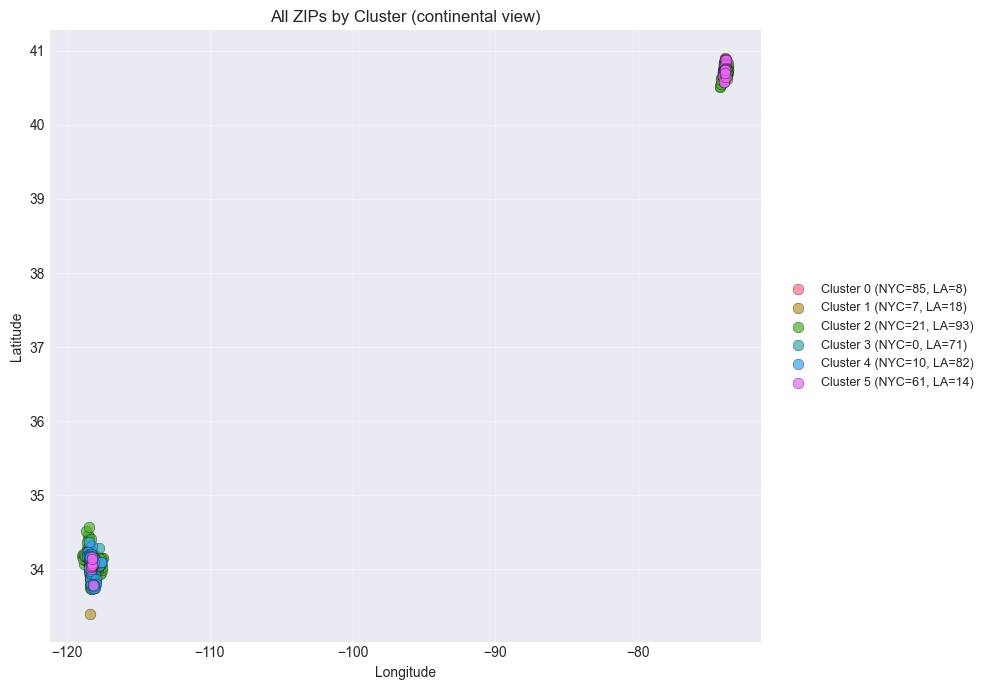

In [30]:
gaz_path = os.path.join(_repo_root, "data", "raw", "2022_Gaz_zcta_national.txt")
gaz = pd.read_csv(gaz_path, sep="\t", dtype={"GEOID": str})
gaz.columns = [c.strip() for c in gaz.columns]
gaz = gaz.rename(columns={"GEOID": "ZIP", "INTPTLAT": "lat", "INTPTLONG": "lon"})
gaz["ZIP"] = gaz["ZIP"].str.zfill(5)
gaz = gaz[["ZIP", "lat", "lon"]]

df_geo = df_clustered.merge(gaz, on="ZIP", how="left")
missing = df_geo["lat"].isna().sum()
print(f"Merged centroids: {len(df_geo) - missing}/{len(df_geo)} ZIPs ({missing} missing)")
df_geo = df_geo.dropna(subset=["lat", "lon"])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, city, title in [
    (axes[0], "NYC", "NYC \u2014 Cluster Assignments"),
    (axes[1], "LA",  "LA \u2014 Cluster Assignments"),
]:
    sub = df_geo[df_geo["city"] == city]
    sc = ax.scatter(sub["lon"], sub["lat"], c=sub["cluster"], cmap="tab10",
                    s=70, alpha=0.85, edgecolors="black", linewidths=0.4,
                    vmin=0, vmax=df_geo["cluster"].max())
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"{title} (n={len(sub)})", fontsize=12)
    ax.set_aspect("equal", adjustable="datalim")
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(sc, ax=ax, ticks=sorted(df_geo["cluster"].unique()))
    cbar.set_label("Cluster")

plt.suptitle("Cluster Geographic Distribution: NYC vs LA", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(_repo_root, "reports", "cluster_map_nyc_la.png"), dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 7))
for cluster_id in sorted(df_geo["cluster"].unique()):
    sub = df_geo[df_geo["cluster"] == cluster_id]
    n_nyc = (sub["city"] == "NYC").sum()
    n_la  = (sub["city"] == "LA").sum()
    ax.scatter(sub["lon"], sub["lat"], s=60, alpha=0.7, edgecolors="black",
               linewidths=0.3, label=f"Cluster {cluster_id} (NYC={n_nyc}, LA={n_la})")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("All ZIPs by Cluster (continental view)", fontsize=12)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(_repo_root, "reports", "cluster_map_combined.png"), dpi=150, bbox_inches="tight")
plt.show()


In [31]:
out_path = os.path.join(_repo_root, "data", "processed", "nyc_la_merged.csv")
eval_data["df_clustered"].to_csv(out_path, index=False)
print(f"Saved {len(eval_data['df_clustered'])} rows to {out_path}")

Saved 470 rows to /Users/spartan/Documents/cmpe255/Project/Urban-Energy-Analytics/data/processed/nyc_la_merged.csv


In [32]:
comparison_df.to_csv(os.path.join(_repo_root, "reports", "algorithm_comparison.csv"))
print("Saved algorithm_comparison.csv")
comparison_df

Saved algorithm_comparison.csv


,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,n_clusters,n_noise
Algorithm,,,,,
Hierarchical (k=3),0.2456,1.5115,138.28,3,0
K-Means (k=3),0.2709,1.3847,154.58,3,0
DBSCAN (eps=0.3),0.8957,0.1350,571.07,2,455


---

## Conclusion

This notebook evaluated three clustering algorithms (K-Means, Agglomerative Hierarchical with Ward linkage, and DBSCAN) using three complementary metrics (Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index). The winning algorithm was selected based on the best combined metric profile.

The results reveal distinct neighborhood energy consumption archetypes across NYC and LA ZIP codes, with structural differences tied to income, housing age, and renter occupancy rates.